In [9]:
!pip install afinn
from afinn import Afinn
import re
import pandas as pd

In [10]:
# Read dataframe

df = pd.read_csv("https://raw.githubusercontent.com/FNXNRNJOYCE/HKU/main/7005/fox_clean_sentiment_analysis.csv", encoding="utf-8")

# Initialize afinn
afinn = Afinn()

df['content_sentiment'] = df['cleaned_text'].apply(afinn.score)

# Check results
print(df[['cleaned_text', 'content_sentiment']].head())

# Statistics of results
print("\n Statistics of Sentiment Analysis Resutls")
print("The Number of Positive Content:", len(df[df['content_sentiment'] > 0]))
print("The Number of Negative Content:", len(df[df['content_sentiment'] < 0]))
print("The Number of Neutral Content:", len(df[df['content_sentiment'] == 0]))

                                        cleaned_text  content_sentiment
0  conservative prolife influencer went viral aft...              -82.0
1  missouri attorney generalcatherine hanaway ann...              -10.0
2  facilities designed discourage abortion seen t...                9.0
3  health wellness committee northwestern univers...               -2.0
4  survey found record number young women interes...               25.0

 Statistics of Sentiment Analysis Resutls
The Number of Positive Content: 262
The Number of Negative Content: 242
The Number of Neutral Content: 10


In [11]:
# Initialize AFINN 
afinn = Afinn()

# List of words that reverse meaning
NEGATION_WORDS = [
        'not', 'no', 'never', 'nothing', 'nowhere', 'noone', 'none', 'dont', 'doesnt', 'didnt', 'cant', 'couldnt', 'wont', 'wouldnt',
        'shouldnt', 'isnt', 'arent', 'havent', 'hasnt', 'hadnt',
        "don't", "doesn't", "didn't", "can't", "couldn't", "won't", 
        "wouldn't", "shouldn't", "isn't", "aren't", "haven't", "hasn't", "hadn't"
]

def analyze_sentiment_negation(text):
    """
    Simple sentiment analysis that handles negation words like 'not'
    """
    # prepare data
    text_str = str(text)
    words = text_str.split()
    
    total_score = 0
    i = 0  
    
    while i < len(words):
        word = words[i]
        word_score = afinn.score(word)
        
        # test negation and emotional word
        if word in NEGATION_WORDS and i + 1 < len(words):
            next_word = words[i + 1]
            next_score = afinn.score(next_word)
            if next_score != 0:
                total_score -= next_score  
                i += 2  
                continue  
        
        
        total_score += word_score
        i += 1  
    
    return total_score

# Test the function
print("TESTING SIMPLE SENTIMENT ANALYSIS:")

test_texts = [
    "I love this movie",           
    "I do not love this movie",    
]

for text in test_texts:
    score = analyze_sentiment_negation(text)
    
    # Determine sentiment label
    if score > 0:
        sentiment = "POSITIVE"
    elif score < 0:
        sentiment = "NEGATIVE"
    else:
        sentiment = "NEUTRAL"

    print(text)
    print("Score:", score, "→", sentiment)
    print()

TESTING SIMPLE SENTIMENT ANALYSIS:
I love this movie
Score: 3.0 → POSITIVE

I do not love this movie
Score: -3.0 → NEGATIVE



In [12]:
# Negation processing
df['content_processed_sentiment'] = df['cleaned_text'].apply(analyze_sentiment_negation)

# Emotional Label
def get_sentiment_label(score):
    if score > 0:
        return 'positive'
    elif score < 0:
        return 'negative'
    else:
        return 'neutral'

df['content_sentiment_label'] =df['content_processed_sentiment'].apply(get_sentiment_label)

# Results
print("Sentiment Analysis Results for the First 10 Articles:")
result_columns = ['title', 'content_processed_sentiment', 'content_sentiment_label']
print(df[result_columns].head(10))

Sentiment Analysis Results for the First 10 Articles:
                                               title  \
0  Pro-life influencer attacked in NYC files laws...   
1  Missouri attorney general takes new legal aim ...   
2  Pro-life pregnancy centers see client increase...   
3  Northwestern Student Committee gets donated ‘r...   
4    Record 40% of young women want to flee US: poll   
5  Florida cites mafia law, hits Planned Parentho...   
6  Florida man facing death penalty for killing 1...   
7  Republican senators blast FDA for expanding ab...   
8  Riley Gaines and Ocasio-Cortez trade barbs as ...   
9  Newsom bails out Planned Parenthood with $140M...   

   content_processed_sentiment content_sentiment_label  
0                        -86.0                negative  
1                        -10.0                negative  
2                          9.0                positive  
3                          2.0                positive  
4                         25.0              

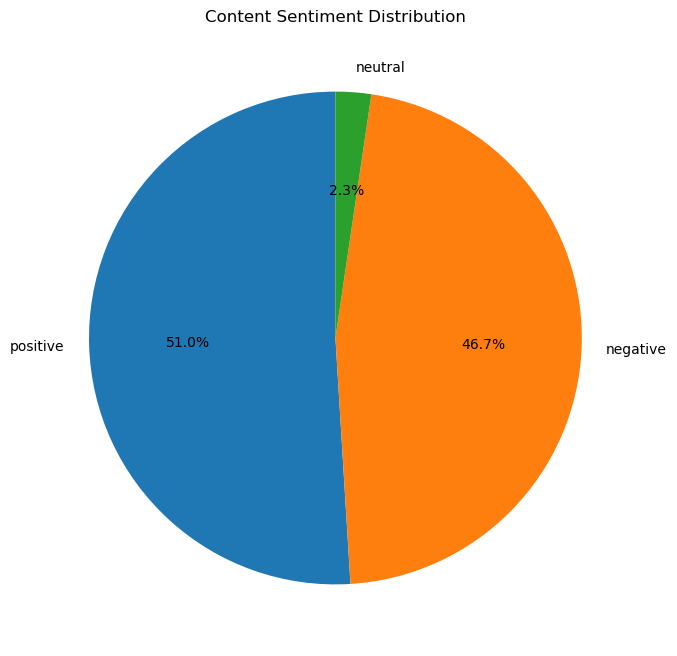

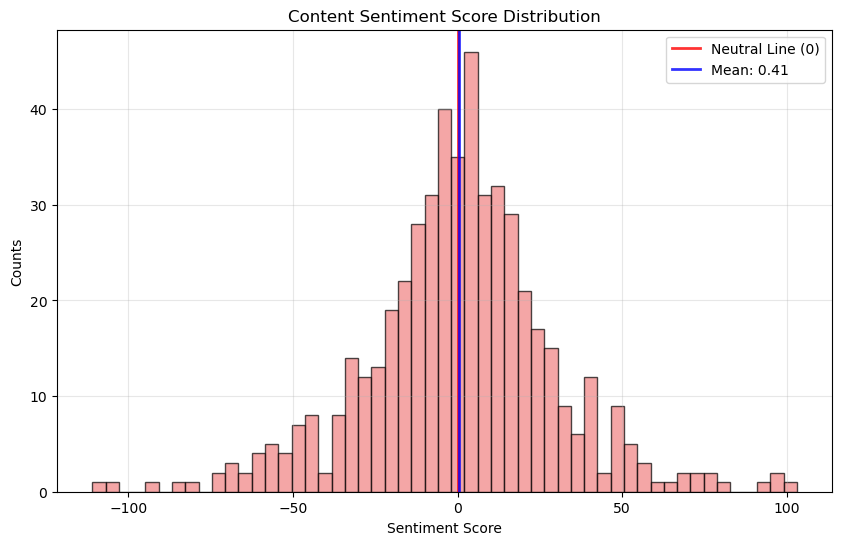

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Figure 1: Content Sentiment Distribution (Pie Chart)
plt.figure(figsize=(8, 8))
content_counts = df['content_sentiment_label'].value_counts()
plt.pie(content_counts.values, labels=content_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Content Sentiment Distribution')
plt.show()

# Figure 2: Content Sentiment Score Distribution (Histogram)
plt.figure(figsize=(10, 6))
data = df['content_processed_sentiment']
mean_score = data.mean()

plt.hist(data, bins=53, alpha=0.7, color='lightcoral', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='-', alpha=0.8, linewidth=2, label='Neutral Line (0)')
plt.axvline(x=mean_score, color='blue', linestyle='-', alpha=0.8, linewidth=2, label='Mean: ' + str(round(mean_score, 2)))

plt.xlabel('Sentiment Score')
plt.ylabel('Counts')
plt.title('Content Sentiment Score Distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



In [14]:
# Generate Summary Report
print("    AFINN Sentiment Analysis Summary Report     ")
print("Total number of articles:",len(df))
print("Average content sentiment score:", df['content_processed_sentiment'].mean())
print("\nContent sentiment distribution:")
print(df['content_sentiment_label'].value_counts())

# Find articles with most extreme sentiments
most_positive_content = df.loc[df['content_processed_sentiment'].idxmax()]
most_negative_content = df.loc[df['content_processed_sentiment'].idxmin()]

print("\nMost positive article:", most_positive_content['cleaned_text'])
print("Sentiment score:", most_positive_content['content_processed_sentiment'])
print("\nMost negative article:", most_negative_content['cleaned_text'])
print("Sentiment score:", most_negative_content['content_processed_sentiment'])

    AFINN Sentiment Analysis Summary Report     
Total number of articles: 514
Average content sentiment score: 0.4143968871595331

Content sentiment distribution:
content_sentiment_label
positive    262
negative    240
neutral      12
Name: count, dtype: int64

Most positive article: little noticed highstakes elections november ballot seats state supreme courts legal precedents set matterssuch abortion election integrity gun rights redistricting other issues state supreme court seats decided voters states guam ballotpedia races partisan nonpartisan retention elections meaning rather deciding between two candidates voters determine whether justice typically appointed governor remain state’s high court some races already decided while other candidates running unopposed november ballot some judicial contests happening key battleground states such arizona michigan north carolina turnout almost certainly high presidential contest across nation federalsupreme courtis tearing back role feder